# One strait, two countries

**Race Rocks, Juan de Fuca Strait — 48.298 N, 123.532 W**

The international boundary runs down the middle of this strait. Race Rocks sits on the Canadian
side of it, about 20 km north of Port Angeles, Washington. Both countries maintain observing
programmes in the same body of water, and a synthesis of "the strait" has to use both.

This notebook asks two things:

1. **Can I assemble a cross-border picture of one strait from a single query?**
2. **Do the two countries' observations of the same water agree?**

The second question is the one that decides whether the first is worth doing. Two tide gauges
20 km apart should see the same tide; two barometers should see the same weather. Where they
disagree, I want to know whether it is the ocean or the plumbing.

Along the way this is a road test of `omnisea` on the hardest case it has: five institutions,
six sampling rates from one minute to one day, two national unit conventions, two vertical
datums, and two ways of stamping a timestamp. Everything below hits live APIs.

In [1]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

import omnisea

# Third-party deprecations only — omnisea's own warnings are how it tells you a join is
# about to be wrong, and this notebook depends on seeing them.
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.width", 150)
pd.set_option("display.max_colwidth", 44)

omnisea.set_timeout(connect=6, read=90)

RACE_ROCKS = omnisea.Site(48.298, -123.532, "Race Rocks", radius_km=60)
WINDOW = ("2026-08-01", "2026-08-15")

print("omnisea", omnisea.__version__)
print("organizations:", ", ".join(omnisea.providers()))
servers = omnisea.erddap_servers()
print(servers[servers["server"].isin(["ioos_sensors", "coastwatch", "nwem", "cioos_pacific"])]
      [["server", "institution", "datasets"]].to_string(index=False))

omnisea 0.1.0
organizations: cioos, cioos_atlantic, cioos_pacific, cioos_slgo, coastwatch, coastwatch_west, dfo, eccc, erddap, glider_dac, hakai, ioos_sensors, noaa_coops, nwem, onc, osmc, salishseacast, usgs
       server                                         institution  datasets
 ioos_sensors                US Integrated Ocean Observing System     27260
cioos_pacific         Fisheries and Oceans Canada / CIOOS Pacific       122
         nwem University of Washington Applied Physics Laboratory       122
   coastwatch                                     NOAA CoastWatch       454


## 1. What does Canada have here?

A 60 km radius from Race Rocks reaches Victoria, Sooke, the Saanich Peninsula and the whole
Canadian shore of the strait. Start with the Canadian sources only, so I can see what each
country contributes before mixing them.

`discover()` is the look-before-you-leap step: it returns station lists and row estimates
without downloading anything.

In [2]:
CANADIAN = ["dfo_tides", "eccc_climate", "eccc_climate_daily", "eccc_swob", "eccc_swob_marine"]
ca_cat = omnisea.discover(sites=RACE_ROCKS, time=WINDOW, providers=CANADIAN)
print(ca_cat)
print()
print(ca_cat.frame.groupby("source")
      .agg(stations=("station_id", "nunique"), nearest_km=("distance_km", "min"))
      .sort_values("nearest_km").round(2).to_string())
print()
print(ca_cat.frame.nsmallest(10, "distance_km")[
    ["source", "station_id", "name", "distance_km", "n_rows_est"]].to_string(index=False))

<Catalog: 62 station(s) from 4 source(s), ~31,360 rows>
            source       station_id                name  distance_km  n_rows_est                          variables
      eccc_climate          1016640          RACE ROCKS         0.04         336 air_pressure, air_temperature, de…
eccc_climate_daily          1016640          RACE ROCKS         0.04          14 air_temperature, integral_wrt_tim…
         eccc_swob          1016640          RACE ROCKS         0.04        2016 air_pressure, air_pressure_at_mea…
         dfo_tides            07080          Pedder Bay         3.98          56 water_surface_height_above_refere…
         dfo_tides            07082        William Head         4.80          56 water_surface_height_above_refere…
         dfo_tides            07030          Becher Bay         6.71          56 water_surface_height_above_refere…
eccc_climate_daily          1015105           METCHOSIN         8.74          14 air_temperature, integral_wrt_tim…
         dfo_tid

Race Rocks itself is an ECCC climate station — 1016640, about 40 m from the coordinates I
typed — and it reports through three different collections at three different rates:
`climate-hourly`, `climate-daily`, and the realtime SWOB feed. That is a gift: three time
grains from one instrument shelter, which is exactly the multi-rate problem I need to solve
for the cross-border join anyway.

`eccc_swob_marine` contributed nothing. There is no Canadian moored buoy within 60 km of here.
Remember that; section 12 comes back to it with the numbers.

## 2. What does the United States have here?

The US side is reached through `erddap_tabledap` pointed at `ioos_sensors`, the IOOS
aggregation that carries NDBC buoys, NOAA CO-OPS tide gauges and a good deal else.

The first attempt fails, and the failure is informative, so I am showing it rather than
hiding it.

In [3]:
try:
    omnisea.discover(sites=RACE_ROCKS, time=WINDOW, providers="erddap_tabledap",
                     erddap_server="ioos_sensors")
except Exception as exc:
    print(f"{type(exc).__name__}: {exc}")

discovery failed for erddap_tabledap: 55 tabledap datasets on https://erddap.sensors.ioos.us/erddap overlap this query, over the 25 dataset ceiling. Describing each one costs a metadata request, so narrow the bbox/time window, name the datasets you want with erddap_datasets=[...], or raise erddap_max_datasets.


Fair enough — describing 55 datasets costs 55 metadata requests, and the ceiling exists so
that a careless query does not do that by accident. The message names the knob, so I turn it.

In [4]:
us_cat = omnisea.discover(sites=RACE_ROCKS, time=WINDOW, providers="erddap_tabledap",
                          erddap_server="ioos_sensors", erddap_max_datasets=80)
print(us_cat)
print()
print(us_cat.frame.nsmallest(8, "distance_km")[
    ["station_id", "name", "lat", "lon", "distance_km"]].to_string(index=False))
print()
for sid in ("noaa_nos_co_ops_9444090", "gov-ndbc-46088"):
    row = us_cat.frame[us_cat.frame.station_id == sid].iloc[0]
    print(f"{sid}  ({row.distance_km:.1f} km)\n    {row.variables}\n")

<Catalog: 35 station(s) from 1 source(s), ~68,472 rows>
         source              station_id                               name  distance_km  n_rows_est                          variables
erddap_tabledap       edu_ucsd_cdip_248    248 - Angeles Point, WA (46267)        15.04        2016 sea_water_velocity_to_direction, …
erddap_tabledap       gov_noaa_awc_kclm PORT ANGELES FAIRCHILD INTERNATIO…        20.27        2016 air_pressure_at_mean_sea_level, d…
erddap_tabledap noaa_nos_co_ops_9444090           Port Angeles, WA (PTAW1)        20.41        2016 air_pressure, air_temperature, se…
erddap_tabledap noaa_nos_co_ops_9443826                   Crescent Bay, WA        20.83         777 sea_surface_height_amplitude_due_…
erddap_tabledap          gov-ndbc-46088 46088 (LLNR 16337) - NEW DUNGENES…        26.38        2016 air_pressure_at_mean_sea_level, d…
erddap_tabledap  gov_usgs_nwis_12045500 ELWHA RIVER AT MCDONALD BR NEAR P…        27.31        2016 river_discharge, water_surface_he…

Two US platforms are worth the whole exercise:

* **NOAA CO-OPS 9444090, Port Angeles** (20.4 km) — a tide gauge that also carries air
  temperature, barometric pressure, water temperature and wind. Directly across the strait.
* **NDBC 46088, New Dungeness** (26.4 km) — a moored buoy in the middle of the strait, with
  air temperature, sea surface temperature, wind and a full wave spectrum.

Between them and Race Rocks I have a north-shore station, a mid-channel buoy and a south-shore
station spanning the boundary. That is a transect.

## 3. Picking the Canadian tide gauge

The nearest Canadian tide gauges to Race Rocks are Pedder Bay (4.0 km), William Head (4.8 km)
and Becher Bay (6.7 km). Their row estimates are the tell.

In [5]:
gauges = ca_cat.frame[ca_cat.frame.source == "dfo_tides"].nsmallest(6, "distance_km")
print(gauges[["station_id", "name", "distance_km", "n_rows_est"]].to_string(index=False))
print()
observing = ca_cat.frame[(ca_cat.frame.source == "dfo_tides") &
                         (ca_cat.frame.n_rows_est > 100)].nsmallest(3, "distance_km")
print("gauges whose estimate implies a continuous water-level series:")
print(observing[["station_id", "name", "distance_km", "n_rows_est"]].to_string(index=False))

station_id                       name  distance_km  n_rows_est
     07080                 Pedder Bay     3.979143          56
     07082               William Head     4.795096          56
     07030                 Becher Bay     6.710045          56
     07024                Sooke Basin    13.942821          56
     07020                      Sooke    16.397155          56
     07110 Esquimalt Government  Hbr.    16.439071          56

gauges whose estimate implies a continuous water-level series:
station_id             name  distance_km  n_rows_est
     07120 Victoria Harbour    18.417950        1400
     07277     Patricia Bay    39.983760        1400
     07260           Sidney    40.377257        1400


Fifty-six rows over fourteen days is four events a day: those are **prediction-only**
stations, where IWLS publishes harmonic high/low times and no measurements. The nearest gauge
that actually records water level is **Victoria Harbour, 07120**, 18.4 km away.

That is a real and slightly annoying result — the closest Canadian instrument to my site is
20 km further from the US gauge than I would like — but it is the honest one, and the row
estimate surfaced it before I downloaded anything.

## 4. One fetch, five institutions, one tree

Now commit. `discover()` again with the exact sources I want, `filter()` down to the five
stations, then `fetch()`.

Two details:

* `resolution="THREE_MINUTES"` asks IWLS for a finer water-level series than the default. It
  is not in the README; I found it in the error message you get from a typo'd keyword.
* `erddap_datasets=[...]` names the two US platforms directly, which skips the metadata
  filtering and the dataset ceiling.

The satellite grid has to be a **second** call. `erddap_datasets` is one global list applied to
every ERDDAP source in the query, and a server rejects the whole list if it does not host every
id in it — so a tabledap id and a griddap id cannot travel together. Grafting the result in
afterwards works, and the graft is carried by everything downstream.

In [6]:
US_STATIONS = ["noaa_nos_co_ops_9444090", "gov-ndbc-46088"]

catalog = omnisea.discover(
    sites=RACE_ROCKS, time=WINDOW,
    providers=["dfo_tides", "eccc_climate", "eccc_climate_daily", "eccc_swob",
               "erddap_tabledap"],
    erddap_server="ioos_sensors", erddap_datasets=US_STATIONS,
    resolution="THREE_MINUTES")

chosen = catalog.filter(station_id=["07120", "1016640"] + US_STATIONS)
print(chosen.frame[["source", "station_id", "name", "distance_km"]].to_string(index=False))

tree = chosen.fetch()

satellite = omnisea.fetch(sites=RACE_ROCKS, time=WINDOW, providers="erddap_griddap",
                          erddap_server="coastwatch",
                          erddap_datasets=["noaacwBLENDEDsstDNDaily"])
tree["/gridded"] = satellite["/gridded"]

print()
print(omnisea.describe(tree)[["node", "n_time", "start", "end"]].to_string(index=False))

            source              station_id                                                              name  distance_km
      eccc_climate                 1016640                                                        RACE ROCKS     0.041421
eccc_climate_daily                 1016640                                                        RACE ROCKS     0.041421
         eccc_swob                 1016640                                                        RACE ROCKS     0.044837
         dfo_tides                   07120                                                  Victoria Harbour    18.417950
   erddap_tabledap noaa_nos_co_ops_9444090                                          Port Angeles, WA (PTAW1)    20.408886
   erddap_tabledap          gov-ndbc-46088 46088 (LLNR 16337) - NEW DUNGENESS - 17 NM NE of Port Angeles, WA    26.376187



                                                node  n_time            start              end
                                /in_situ/tides/07120    6721 2026-08-01 00:00 2026-08-15 00:00
                       /predictions/tides_hilo/07120      42 2026-08-01 03:08 2026-08-14 17:49
                            /in_situ/weather/1016640     337 2026-08-01 00:00 2026-08-15 00:00
                      /in_situ/weather_daily/1016640      15 2026-08-01 00:00 2026-08-15 00:00
                   /in_situ/weather_realtime/1016640   19672 2026-08-01 00:00 2026-08-14 23:20
  /gridded/erddap/coastwatch/noaacwBLENDEDsstDNDaily      14 2026-08-01 12:00 2026-08-14 12:00
         /in_situ/erddap/ioos_sensors/gov-ndbc-46088    2043 2026-08-01 00:00 2026-08-15 00:00
/in_situ/erddap/ioos_sensors/noaa_nos_co_ops_9444090    3361 2026-08-01 00:00 2026-08-15 00:00


Observations and predictions live in separate branches, and the satellite grid lands under
`/gridded` rather than being flattened into the point series. Here is the same tree sorted by
sampling interval, which is the thing that makes the join hard.

In [7]:
grain = []
for node in tree.subtree:
    ds = node.dataset
    if "time" not in ds.coords or not ds.data_vars:
        continue
    stamps = pd.DatetimeIndex(ds["time"].values)
    grain.append({"node": node.path.split("/", 2)[-1],
                  "institution": (ds.attrs.get("institution") or "")[:46],
                  "n_time": len(stamps),
                  "median step": stamps.to_series().diff().median(),
                  "n_vars": len(ds.data_vars)})
print(pd.DataFrame(grain).sort_values("median step").to_string(index=False))

                                       node                                    institution  n_time     median step  n_vars
                   weather_realtime/1016640 Environment and Climate Change Canada / Meteor   19672 0 days 00:01:00     111
                                tides/07120 Fisheries and Oceans Canada / Canadian Hydrogr    6721 0 days 00:03:00       3
erddap/ioos_sensors/noaa_nos_co_ops_9444090 NOAA Center for Operational Oceanographic Prod    3361 0 days 00:06:00      19
         erddap/ioos_sensors/gov-ndbc-46088          NOAA National Data Buoy Center (NDBC)    2043 0 days 00:10:00      37
                            weather/1016640 Environment and Climate Change Canada / Meteor     337 0 days 01:00:00       7
                           tides_hilo/07120 Fisheries and Oceans Canada / Canadian Hydrogr      42 0 days 07:08:00       3
                      weather_daily/1016640 Environment and Climate Change Canada / Meteor      15 1 days 00:00:00       9
  erddap/coastwa

Six grains from one minute to one day, five institutions, in one object:

| | |
|---|---|
| 1 min | ECCC SWOB realtime, Race Rocks — **111 variables** from one station |
| 3 min | DFO IWLS water level, Victoria Harbour |
| 6 min | NOAA CO-OPS, Port Angeles |
| 10 min | NOAA NDBC buoy 46088 |
| 1 h | ECCC climate-hourly, Race Rocks |
| ~7 h | DFO predicted tidal extrema (an event series, not a rate) |
| 1 day | ECCC climate-daily, and NOAA CoastWatch blended SST |

One caveat about reproducibility before going further: **SWOB is a rolling ~30-day archive**.
Re-running this notebook a day later gives a slightly different row count and end time for
that node as files roll off the back. Every SWOB number below is from the run whose output you
are reading.

## 5. Units: the part that decides whether any of this is publishable

Before joining anything, look at what the units actually say. This is the cross-border risk in
one table.

In [8]:
WANTED = ("air_temperature", "air_pressure", "air_pressure_at_mean_sea_level", "wind_speed",
          "sea_surface_temperature", "sea_water_temperature", "analysed_sst",
          "water_surface_height_above_reference_datum", "sea_surface_height_above_sea_level",
          "sea_surface_height_amplitude_due_to_geocentric_ocean_tide")
rows = []
for node in tree.subtree:
    ds = node.dataset
    for name, var in ds.data_vars.items():
        if str(name) in WANTED:
            rows.append({"variable": str(name),
                         "node": node.path.split("/")[-1],
                         "country": "CA" if ds.attrs.get("provider") in ("dfo", "eccc") else "US",
                         "units": var.attrs.get("units"),
                         "cf_units": var.attrs.get("cf_units"),
                         "source_field": var.attrs.get("source_field", "-")})
inventory = pd.DataFrame(rows).sort_values(["variable", "country"])
print(inventory.to_string(index=False))

                                                 variable                    node country          units cf_units                                                         source_field
                                             air_pressure                 1016640      CA            kPa       Pa                                                                    -
                                             air_pressure                 1016640      CA            hPa       Pa                                                                    -
                                             air_pressure noaa_nos_co_ops_9444090      US      millibars      NaN                                                         air_pressure
                           air_pressure_at_mean_sea_level                 1016640      CA            hPa       Pa                                                                    -
                           air_pressure_at_mean_sea_level          gov-ndbc-46088    

Four spellings of degrees Celsius (`degC`, `°C`, `degree_Celsius`, `degree_C`), three of
pressure (`kPa`, `hPa`, `millibars`), three of wind speed (`km h-1`, `km/h`, `m.s-1`).
Nothing has been rescaled — the values are as each agency published them, and the `units`
attribute says which those are. That is the right default.

But look at the `cf_units` column. It is filled in for every Canadian variable and empty for
every American one. `cf_units` is the target that `to_cf_units=True` converts to. Which means
the switch that promises uniform units is going to convert one country and not the other.

### 5a. `to_cf_units=True`, side by side

A short two-day window on three stations, fetched twice — once with the default, once with
`to_cf_units=True` — and the means compared.

In [9]:
PROBE = ("2026-08-01", "2026-08-03")
probe = omnisea.discover(sites=RACE_ROCKS, time=PROBE,
                         providers=["eccc_climate", "erddap_tabledap"],
                         erddap_server="ioos_sensors", erddap_datasets=US_STATIONS)
probe = probe.filter(station_id=["1016640"] + US_STATIONS)
raw_tree = probe.fetch(to_cf_units=False)
cf_tree = probe.fetch(to_cf_units=True)

TARGETS = [("/in_situ/weather/1016640", "air_temperature", "CA  ECCC Race Rocks"),
           ("/in_situ/weather/1016640", "air_pressure", "CA  ECCC Race Rocks"),
           ("/in_situ/weather/1016640", "wind_speed", "CA  ECCC Race Rocks"),
           ("/in_situ/erddap/ioos_sensors/noaa_nos_co_ops_9444090", "air_temperature",
            "US  CO-OPS Port Angeles"),
           ("/in_situ/erddap/ioos_sensors/noaa_nos_co_ops_9444090", "air_pressure",
            "US  CO-OPS Port Angeles"),
           ("/in_situ/erddap/ioos_sensors/gov-ndbc-46088", "air_temperature", "US  NDBC 46088"),
           ("/in_situ/erddap/ioos_sensors/gov-ndbc-46088", "wind_speed", "US  NDBC 46088")]
comparison = []
for path, var, who in TARGETS:
    before, after = raw_tree[path].dataset[var], cf_tree[path].dataset[var]
    comparison.append({"station": who, "variable": var,
                       "units (default)": before.attrs.get("units"),
                       "mean (default)": float(np.nanmean(before.values)),
                       "units (to_cf_units)": after.attrs.get("units"),
                       "mean (to_cf_units)": float(np.nanmean(after.values)),
                       "converted": before.attrs.get("units") != after.attrs.get("units")})
print(pd.DataFrame(comparison).round(3).to_string(index=False))

                station        variable units (default)  mean (default) units (to_cf_units)  mean (to_cf_units)  converted
    CA  ECCC Race Rocks air_temperature            degC          14.871                   K             288.021       True
    CA  ECCC Race Rocks    air_pressure             kPa         101.621                  Pa          101620.612       True
    CA  ECCC Race Rocks      wind_speed          km h-1          38.286               m s-1              10.635       True
US  CO-OPS Port Angeles air_temperature  degree_Celsius          14.654      degree_Celsius              14.654      False
US  CO-OPS Port Angeles    air_pressure       millibars        1021.125           millibars            1021.125      False
         US  NDBC 46088 air_temperature  degree_Celsius          13.119      degree_Celsius              13.119      False
         US  NDBC 46088      wind_speed           m.s-1           5.284               m.s-1               5.284      False


/var/folders/hd/3rqqvs_j7ns9lp665gvzv0_w0000gn/T/ipykernel_38269/3240630905.py:7: UserWarning: to_cf_units=True converted nothing from: erddap_tabledap (24 variable(s), e.g. air_pressure). Those sources publish the units their numbers are in but not how to reach canonical CF units, and omnisea will not guess a scale factor for someone else's data — so this result mixes unit systems. Every column's units are in the node attrs and in align()'s attrs["omnisea_units"]; check them before comparing columns across sources.
  cf_tree = probe.fetch(to_cf_units=True)


The conversions omnisea *does* perform are correct: 14.871 degC + 273.15 = 288.021 K,
101.621 kPa x 1000 = 101620.6 Pa, 38.286 km/h / 3.6 = 10.635 m/s. No complaint there.

The problem is the `converted` column. Every Canadian variable converted; **no American
variable did**, because the ERDDAP adapter reads each dataset's own metadata and that metadata
does not carry a CF-canonical target. So on this cross-border tree, `to_cf_units=True` takes a
frame in which Canadian and American temperatures were at least both in degrees Celsius, and
leaves one side in kelvin.

Watch what that does to an aligned frame.

In [10]:
cf_hourly = omnisea.align(cf_tree, freq="1h")
temperature_columns = [c for c in cf_hourly.columns if c.startswith("air_temperature")]
side_by_side = cf_hourly[temperature_columns].head(4).round(2)
side_by_side.loc["units ->"] = [cf_hourly.attrs["omnisea_units"].get(c)
                                for c in temperature_columns]
print(side_by_side.to_string())

                    air_temperature@1016640 air_temperature@noaa_nos_co_ops_9444090 air_temperature@gov-ndbc-46088
time                                                                                                              
2026-08-01 00:00:00                  290.15                                   16.35                          13.53
2026-08-01 01:00:00                  290.55                                   16.66                          13.47
2026-08-01 02:00:00                  290.85                                   17.04                          13.55
2026-08-01 03:00:00                  290.55                                   16.93                          13.32
units ->                                  K                          degree_Celsius                 degree_Celsius


290.15 sitting next to 16.35 in three columns all called `air_temperature`. The units *are*
recorded — `align()` writes them into `frame.attrs["omnisea_units"]`, which is how I printed
that last row — but nothing downstream reads them, and a plot or a regression across those
three columns is nonsense.

**For the rest of this notebook I use the default (`to_cf_units=False`).** On a cross-border
tree, provider units are less dangerous than half-converted ones: at least everything
temperature is in some flavour of Celsius, and the mismatches that remain are ones I can see.

## 6. Do I believe the numbers? Three checks against the raw APIs

Before building anything on this tree, check that what omnisea handed me is what the agencies
published. Three different traps, one per country's plumbing.

In [11]:
import requests

print("--- 1. ECCC climate-hourly, RACE ROCKS 1016640 ---")
print("    (this API FILTERS on LOCAL_DATE but PUBLISHES UTC_DATE — an eight-hour trap)")
answer = requests.get("https://api.weather.gc.ca/collections/climate-hourly/items",
                      params={"CLIMATE_IDENTIFIER": "1016640",
                              "datetime": "2026-08-03T00:00:00Z/2026-08-03T01:00:00Z",
                              "limit": 5, "f": "json"}, timeout=60).json()
for feature in answer["features"]:
    p = feature["properties"]
    print("    raw:", {k: p[k] for k in
                       ("LOCAL_DATE", "UTC_DATE", "TEMP", "WIND_SPEED", "STATION_PRESSURE")})
window = tree["/in_situ/weather/1016640"].dataset.sel(
    time=slice("2026-08-03T08:00", "2026-08-03T09:00"))
print("    omnisea:")
print(pd.DataFrame({"air_temperature": window.air_temperature.values,
                    "wind_speed": window.wind_speed.values,
                    "air_pressure": window.air_pressure.values},
                   index=pd.DatetimeIndex(window.time.values)).to_string())

--- 1. ECCC climate-hourly, RACE ROCKS 1016640 ---
    (this API FILTERS on LOCAL_DATE but PUBLISHES UTC_DATE — an eight-hour trap)


    raw: {'LOCAL_DATE': '2026-08-03 01:00:00', 'UTC_DATE': '2026-08-03T09:00:00', 'TEMP': 12.1, 'WIND_SPEED': 24, 'STATION_PRESSURE': 102.06}
    raw: {'LOCAL_DATE': '2026-08-03 00:00:00', 'UTC_DATE': '2026-08-03T08:00:00', 'TEMP': 12.7, 'WIND_SPEED': 18, 'STATION_PRESSURE': 102.05}
    omnisea:
                     air_temperature  wind_speed  air_pressure
2026-08-03 08:00:00             12.7        18.0        102.05
2026-08-03 09:00:00             12.1        24.0        102.06


The trap here is real: `climate-hourly` accepts a `datetime` filter against `LOCAL_DATE`
while publishing `UTC_DATE` alongside it. Ask for `2026-08-03T00:00Z/01:00Z` and you get back
the rows for local hours 00 and 01, whose UTC stamps are 08:00 and 09:00.

The raw record with `LOCAL_DATE = 2026-08-03 00:00` carries `UTC_DATE = 2026-08-03T08:00` and
`TEMP = 12.7`. omnisea stamps 12.7 at `2026-08-03 08:00`. It used the UTC field.

If it had taken the local stamp at face value the whole Canadian record would sit eight hours
early against the American one, and every cross-border lag below would be meaningless.
**This is the single most important thing omnisea got right in this notebook.**

In [12]:
print("--- 2. NDBC 46088 straight off the IOOS ERDDAP ---")
csv = requests.get("https://erddap.sensors.ioos.us/erddap/tabledap/gov-ndbc-46088.csv"
                   "?time,air_temperature,sea_surface_temperature,wind_speed"
                   "&time%3E=2026-08-03T00:00:00Z&time%3C=2026-08-03T00:30:00Z",
                   timeout=90).text
print("    " + "\n    ".join(csv.strip().splitlines()))
buoy = tree["/in_situ/erddap/ioos_sensors/gov-ndbc-46088"].dataset.sel(
    time=slice("2026-08-03T00:00", "2026-08-03T00:30"))
print("    omnisea:")
print(pd.DataFrame({"air_temperature": buoy.air_temperature.values,
                    "sea_surface_temperature": buoy.sea_surface_temperature.values,
                    "wind_speed": buoy.wind_speed.values},
                   index=pd.DatetimeIndex(buoy.time.values)).to_string())

--- 2. NDBC 46088 straight off the IOOS ERDDAP ---


    time,air_temperature,sea_surface_temperature,wind_speed
    UTC,degree_Celsius,degree_Celsius,m.s-1
    2026-08-03T00:00:00Z,12.7,11.3,5.0
    2026-08-03T00:09:00Z,NaN,NaN,NaN
    2026-08-03T00:10:00Z,12.6,11.3,5.0
    2026-08-03T00:20:00Z,12.6,11.4,6.0
    2026-08-03T00:30:00Z,12.6,11.3,5.0
    omnisea:
                     air_temperature  sea_surface_temperature  wind_speed
2026-08-03 00:00:00             12.7                     11.3         5.0
2026-08-03 00:09:00              NaN                      NaN         NaN
2026-08-03 00:10:00             12.6                     11.3         5.0
2026-08-03 00:20:00             12.6                     11.4         6.0
2026-08-03 00:30:00             12.6                     11.3         5.0


Third check, and a different kind of trap: IWLS caps a request window by resolution and
chunks around it. The node records the exact endpoint it read, so the raw call below is the
same one omnisea made.

In [13]:
print("--- 3. DFO IWLS, Victoria Harbour 07120 ---")
endpoint = tree["/in_situ/tides/07120"].dataset.attrs["source_url"]
print("    node records its own source_url:", endpoint)
raw = requests.get(endpoint.split("?")[0],
                   params={"time-series-code": "wlo", "from": "2026-08-03T00:00:00Z",
                           "to": "2026-08-03T00:07:00Z"}, timeout=60).json()
print("    raw:", [(d["eventDate"], d["value"]) for d in raw])
print("    omnisea:", tree["/in_situ/tides/07120"].dataset[
    "water_surface_height_above_reference_datum"]
    .sel(time=slice("2026-08-03T00:00", "2026-08-03T00:06")).to_series().to_dict())

--- 3. DFO IWLS, Victoria Harbour 07120 ---
    node records its own source_url: https://api-iwls.dfo-mpo.gc.ca/api/v1/stations/5cebf1df3d0f4a073c4bbd1e/data?time-series-code=wlo


    raw: [('2026-08-03T00:00:00Z', 2.101), ('2026-08-03T00:01:00Z', 2.105), ('2026-08-03T00:02:00Z', 2.109), ('2026-08-03T00:03:00Z', 2.113), ('2026-08-03T00:04:00Z', 2.119), ('2026-08-03T00:05:00Z', 2.125), ('2026-08-03T00:06:00Z', 2.131), ('2026-08-03T00:07:00Z', 2.137)]
    omnisea: {Timestamp('2026-08-03 00:00:00'): 2.101, Timestamp('2026-08-03 00:03:00'): 2.113, Timestamp('2026-08-03 00:06:00'): 2.131}


Both match to the last digit, including the buoy's `NaN` row at 00:09 — omnisea carried the
gap through rather than quietly dropping the timestamp. The IWLS series is thinned to the
three-minute resolution I asked for; the values at the shared stamps are identical.

Three sources, three formats, three checks, no discrepancies. The numbers are the agencies'
numbers.

## 7. Joining six sampling rates onto one regular grid

`align(freq=...)` resamples every node onto a common grid. What makes it more than
`.resample()` is that the rule per variable comes from CF `cell_methods` — a daily
precipitation total is summed, a daily maximum is maxed, an instantaneous tide height is
interpolated.

In [14]:
hourly = omnisea.align(tree, freq="1h")
print("aligned frame:", hourly.shape)
print("alignment    :", hourly.attrs["omnisea_alignment"])
print("time zone    :", hourly.attrs["omnisea_time_zone"])
print()
INSPECT = ["water_surface_height_above_reference_datum",
           "sea_surface_height_above_sea_level",
           "air_temperature@1016640", "air_temperature@1016640:in",
           "air_temperature_max", "sea_surface_temperature",
           "wind_speed@1016640", "wind_speed_of_gust@1016640"]
for column in INSPECT:
    if column in hourly.columns:
        print(f"  {column:<44s} {hourly.attrs['omnisea_aggregation'][column]}")

skipping node /gridded/erddap/coastwatch/noaacwBLENDEDsstDNDaily in align(): it is a 14x22x33 grid, not a time series — align() joins series onto one time axis and a grid has latitude, longitude besides time. Pick the cells you want first (ds.sel(latitude=..., longitude=..., method='nearest') or .isel()), then add_local() the result, which is what makes the cost of reading a grid explicit rather than accidental.


aligned frame: (344, 129)
alignment    : resampled to 1h
time zone    : UTC (naive index; all omnisea times are UTC)

  water_surface_height_above_reference_datum   mean
  sea_surface_height_above_sea_level           mean
  air_temperature@1016640                      mean
  air_temperature_max                          ffill (upsampled), read in station-local time (America/Vancouver)
  sea_surface_temperature                      mean
  wind_speed@1016640                           mean
  wind_speed_of_gust@1016640                   ffill (upsampled), read in station-local time (America/Vancouver)


Two of those lines matter.

`air_temperature_max` says **"ffill (upsampled), read in station-local time
(America/Vancouver)"**. A daily maximum has no meaning at 03:00, so forward-filling it across
its own day is the honest choice, and the local-time note says omnisea understood that ECCC
labels a daily summary by *local* calendar date rather than by a UTC instant. Getting that
wrong would smear each daily value seven hours off.

Everything instantaneous says `mean` on the way down to hourly, which for a tide sampled every
three minutes is right.

But there is a name in that list I should not have had to guess at.

### 7a. Three columns called `air_temperature@1016640`

Station 1016640 appears in three ECCC nodes — hourly, daily and SWOB — so `align()` has to
disambiguate three columns with the same variable name and the same station id.

In [15]:
candidates = [c for c in hourly.columns if c.startswith("air_temperature@1016640")]
print("columns:", candidates)
print()
print(hourly[candidates].head(4).round(2).to_string())
print()
for column in candidates:
    print(f"  {column:<32s} distinct values = {hourly[column].nunique():4d}   "
          f"{hourly.attrs['omnisea_aggregation'][column]}")

columns: ['air_temperature@1016640', 'air_temperature@1016640:weather_daily', 'air_temperature@1016640:weather_realtime']

                     air_temperature@1016640  air_temperature@1016640:weather_daily  air_temperature@1016640:weather_realtime
time                                                                                                                         
2026-08-01 00:00:00                     17.0                                    NaN                                     16.34
2026-08-01 01:00:00                     17.4                                    NaN                                     17.97
2026-08-01 02:00:00                     17.7                                    NaN                                     18.06
2026-08-01 03:00:00                     17.4                                    NaN                                     16.88

  air_temperature@1016640          distinct values =   93   mean
  air_temperature@1016640:weather_daily distinct values

`air_temperature@1016640`, `air_temperature@1016640:in`, `air_temperature@1016640:in#2`.

The suffix is the first token of the branch name, and all three nodes live under `/in_situ/`,
so all three want to be called `:in`. The reader gets `:in` and `:in#2`, which identify
nothing. In this frame the plain one is climate-hourly, `:in` is the **daily summary** (13
distinct values over 14 days) and `:in#2` is the 1-minute SWOB feed (328). The distinct-value
count and the aggregation string are the only way to tell, and the daily one has completely
different semantics from the other two.

The scheme works where it was designed to — `reviewed@07120` versus `reviewed@07120:predictions`
reads perfectly — but under one branch it degrades to noise.

### 7b. What ECCC means by "daily mean temperature"

Since I am about to compare Canadian and American temperatures, one more check. ECCC's daily
`air_temperature` arrives with `cell_methods = "time: mean"`. Is it a mean?

In [16]:
daily_node = tree["/in_situ/weather_daily/1016640"].dataset
hourly_node = tree["/in_situ/weather/1016640"].dataset
check = pd.DataFrame({
    "ECCC daily 'air_temperature'": daily_node.air_temperature.to_series(),
    "(min + max) / 2": (daily_node.air_temperature_min.to_series()
                        + daily_node.air_temperature_max.to_series()) / 2,
    "mean of the 24 hourly obs": hourly_node.air_temperature.to_series().resample("1D").mean(),
}).dropna()
print(check.round(3).head(8).to_string())
print()
print("largest |daily value - (min+max)/2| : %.3f degC" %
      (check.iloc[:, 0] - check.iloc[:, 1]).abs().max())
print("mean (daily 'mean' - true hourly mean): %+.2f degC" %
      (check.iloc[:, 0] - check.iloc[:, 2]).mean())
print("cell_methods omnisea attaches        :",
      daily_node.air_temperature.attrs.get("cell_methods"))

            ECCC daily 'air_temperature'  (min + max) / 2  mean of the 24 hourly obs
time                                                                                
2026-08-01                          15.0            15.05                     15.821
2026-08-02                          13.8            13.75                     13.871
2026-08-03                          15.6            15.55                     14.362
2026-08-04                          19.4            19.45                     16.675
2026-08-05                          18.6            18.55                     17.008
2026-08-06                          13.8            13.75                     13.004
2026-08-07                          13.1            13.15                     11.275
2026-08-08                          16.5            16.45                     14.729

largest |daily value - (min+max)/2| : 0.050 degC
mean (daily 'mean' - true hourly mean): +1.10 degC
cell_methods omnisea attaches        : time: mean

It is the **midrange**, (Tmax + Tmin)/2 — the Canadian climatological convention — and at
Race Rocks in August it runs **1.10 degC warmer** than the average of the 24 hourly readings
from the same shelter. That is not omnisea's arithmetic; it is ECCC's definition. But omnisea
labels it `time: mean` with `long_name = "Daily mean air temperature"`, and `align()` will
happily take the mean of those midranges when downsampling to a week.

If I were comparing Canadian daily means against American daily means computed from hourly
data, that 1.1 degC would be a fabricated warm bias in the Canadian record. Worth writing on
the methods page.

## 8. Joining onto my own irregular timestamps

The other half of `align()` takes a frame of *my* timestamps and joins everything onto them.

My timestamps are the moments of high and low water on the Canadian side. I detect them
myself: a 30-minute centred mean to suppress harbour seiche and sensor noise, then peaks at
least four hours apart and at least 10 cm prominent. Two columns of my own travel with them —
the level I measured at that instant and whether it was a high or a low.

This is a real question, not a demo: *what does the American side of the strait read at the
moment of Canadian high water?*

In [17]:
ca_level = tree["/in_situ/tides/07120"].dataset[
    "water_surface_height_above_reference_datum"].to_series()
us_level = tree["/in_situ/erddap/ioos_sensors/noaa_nos_co_ops_9444090"].dataset[
    "sea_surface_height_above_sea_level"].to_series().dropna()


def turning_points(series, prominence=0.10, min_hours=4.0, smooth="30min"):
    """Times of high and low water in a water-level series."""
    smoothed = series.rolling(smooth, center=True).mean().dropna()
    step = smoothed.index.to_series().diff().median() / pd.Timedelta(minutes=1)
    apart = max(int(min_hours * 60 / step), 1)
    highs, _ = find_peaks(smoothed.values, distance=apart, prominence=prominence)
    lows, _ = find_peaks(-smoothed.values, distance=apart, prominence=prominence)
    return pd.concat([
        pd.DataFrame({"level": smoothed.values[highs], "state": "high"},
                     index=smoothed.index[highs]),
        pd.DataFrame({"level": smoothed.values[lows], "state": "low"},
                     index=smoothed.index[lows]),
    ]).sort_index()


ca_turns, us_turns = turning_points(ca_level), turning_points(us_level)
print(f"turning points detected: CA {len(ca_turns)} ({(ca_turns.state == 'high').sum()} high), "
      f"US {len(us_turns)} ({(us_turns.state == 'high').sum()} high)")
print("DFO's own predicted extrema over the same window:",
      tree["/predictions/tides_hilo/07120"].dataset.sizes["time"])

occupations = ca_turns.reset_index()
occupations.columns = ["time", "ca_level_m", "tide_state"]
occupations["time"] = occupations["time"].dt.tz_localize("UTC")   # be explicit; omnisea warns otherwise
print()
print(occupations.head(6).to_string(index=False))

turning points detected: CA 40 (20 high), US 41 (20 high)
DFO's own predicted extrema over the same window: 42

                     time  ca_level_m tide_state
2026-08-01 03:24:00+00:00      2.4218       high
2026-08-01 06:30:00+00:00      2.1996        low
2026-08-01 10:24:00+00:00      2.4492       high
2026-08-01 18:21:00+00:00      0.7742        low
2026-08-02 01:42:00+00:00      2.3490       high
2026-08-02 06:51:00+00:00      1.8972        low


Forty detected against DFO's forty-two predicted — close enough that the detector is
finding the real turning points and not harbour noise. Now join everything onto those forty
instants.

In [18]:
slack = omnisea.align(tree, on=occupations, tolerance="20min")
print("joined onto my timestamps:", slack.shape)
LOOK = ["ca_level_m", "tide_state", "sea_surface_height_above_sea_level",
        "sea_surface_temperature", "air_temperature@gov-ndbc-46088",
        "wind_speed@1016640", "air_temperature_max"]
print(slack[LOOK].head(6).round(3).to_string())
print()
print("carried through from my own frame:", slack.attrs["omnisea_carried"])
print()
for column in LOOK:
    print(f"  {column:<40s} {slack.attrs['omnisea_aggregation'].get(column)}")

skipping node /gridded/erddap/coastwatch/noaacwBLENDEDsstDNDaily in align(): it is a 14x22x33 grid, not a time series — align() joins series onto one time axis and a grid has latitude, longitude besides time. Pick the cells you want first (ds.sel(latitude=..., longitude=..., method='nearest') or .isel()), then add_local() the result, which is what makes the cost of reading a grid explicit rather than accidental.


joined onto my timestamps: (40, 131)
                     ca_level_m tide_state  sea_surface_height_above_sea_level  sea_surface_temperature  air_temperature@gov-ndbc-46088  wind_speed@1016640  air_temperature_max
time                                                                                                                                                                            
2026-08-01 03:24:00       2.422       high                               1.756                     11.3                            13.3                 NaN                  NaN
2026-08-01 06:30:00       2.200        low                               1.436                     11.3                            13.7                 NaN                  NaN
2026-08-01 10:24:00       2.449       high                               1.897                     11.2                            13.6                 NaN                 17.6
2026-08-01 18:21:00       0.774        low                              -0.026

The match report is the useful part. Instantaneous series matched 39 or 40 out of 40 within
20 minutes. `air_temperature_max` matched **backward within its own 1-day interval, read in
station-local time** — a sample gets the maximum for the local day it fell in, not the nearest
midnight stamp — and missed 2 of 40, the ones falling in a local day outside the window.

`wind_speed@1016640` matched only **25 of 40**. That is not a bug: ECCC's hourly wind at Race
Rocks has gaps in this fortnight, and the alternative to reporting 25/40 is a column of silent
`NaN`. This is the number I would have missed by eye.

And my own two columns came through untouched, listed under `omnisea_carried`. They are also
immune from the pruning in the next section, which is the right rule — correlation with *my*
response is signal, not redundancy.

## 9. What is redundant across the border?

131 columns from five institutions. Some of it is the same physical signal several times over.
`correlations()` finds the near-duplicates and, crucially, reports the sample count each `r`
was computed on.

In [19]:
pairs = omnisea.correlations(hourly, threshold=0.95)
print(f"{len(pairs)} pairs at |r| >= 0.95 among {hourly.shape[1]} columns")
print()
print(pairs.head(10).to_string(index=False))

305 pairs at |r| >= 0.95 among 129 columns

                                     feature_a                              feature_b        r   n
      air_temperature@1016640:weather_realtime                             air_temp_1 1.000000 333
                             data_avail_pst1mt                      data_avail_pst1hr 1.000000 333
                     max_pk_wnd_spd_10m_pst1hr               max_wnd_spd_10m_pst1hr_1 0.999997 114
                       max_wnd_spd_pst1hr_tm_1                max_wnd_spd_pst1hr_tm_2 0.999988 160
dew_point_temperature@1016640:weather_realtime                   avg_dwpt_temp_pst1hr 0.999986 326
                        avg_wnd_spd_10m_pst1mt                avg_wnd_spd_10m_pst2mts 0.999981 333
                     wnd_dir_10m_pst1hr_pk_spd           wnd_dir_10m_pst1hr_max_spd_1 0.999971 114
    relative_humidity@1016640:weather_realtime                     min_rel_hum_pst1mt 0.999945 333
    relative_humidity@1016640:weather_realtime                   

Most of that is SWOB talking to itself: `air_temperature@1016640:in#2` and `air_temp_1` at
r = 1.000 are literally the same measurement published under two names in the same file, and
the one-minute, two-minute and ten-minute wind averages are near-copies of each other. That is
what 111 variables from one station buys you, and it is exactly the case `drop_correlated()`
exists for.

The interesting question is different: **which pairs straddle the border?**

In [20]:
CANADIAN_PROVIDERS = {"dfo", "eccc"}
owner_of_station, owner_of_variable = {}, {}
for node in tree.subtree:
    ds = node.dataset
    if not ds.data_vars:
        continue
    who = "CA" if ds.attrs.get("provider") in CANADIAN_PROVIDERS else "US"
    station = str(ds.attrs.get("station_id") or ds.attrs.get("erddap_dataset_id") or "")
    owner_of_station[station] = who
    for name in ds.data_vars:
        owner_of_variable.setdefault(str(name), who)


def owner(column):
    base, _, station = column.partition("@")
    if station:
        return owner_of_station.get(station.split(":")[0].split("#")[0], "?")
    return owner_of_variable.get(base, "?")


print("columns by country:", pd.Series([owner(c) for c in hourly.columns]).value_counts().to_dict())

cross = pairs[[owner(a) != owner(b) for a, b in zip(pairs.feature_a, pairs.feature_b)]]
units = hourly.attrs["omnisea_units"]
report = cross.assign(
    A=[f"{owner(c)}  {c}" for c in cross.feature_a],
    units_a=[units.get(c, "-") for c in cross.feature_a],
    mean_a=[hourly[c].mean() for c in cross.feature_a],
    B=[f"{owner(c)}  {c}" for c in cross.feature_b],
    units_b=[units.get(c, "-") for c in cross.feature_b],
    mean_b=[hourly[c].mean() for c in cross.feature_b])
print(f"\n{len(cross)} cross-border pairs at |r| >= 0.95:")
print(report[["A", "units_a", "mean_a", "B", "units_b", "mean_b", "r", "n"]]
      .round(3).to_string(index=False))

columns by country: {'CA': 98, 'US': 31}

8 cross-border pairs at |r| >= 0.95:
                                             A units_a   mean_a                                                             B   units_b   mean_b     r   n
    CA  air_pressure_at_mean_sea_level@1016640     hPa 1017.676             US  air_pressure_at_mean_sea_level@gov-ndbc-46088 millibars 1017.360 0.997 158
     CA  air_pressure@1016640:weather_realtime     hPa 1013.531             US  air_pressure_at_mean_sea_level@gov-ndbc-46088 millibars 1017.360 0.996 331
                      CA  air_pressure@1016640     kPa  101.350             US  air_pressure_at_mean_sea_level@gov-ndbc-46088 millibars 1017.360 0.995 335
     CA  air_pressure@1016640:weather_realtime     hPa 1013.531                      US  air_pressure@noaa_nos_co_ops_9444090 millibars 1018.523 0.993 333
    CA  air_pressure_at_mean_sea_level@1016640     hPa 1017.676                      US  air_pressure@noaa_nos_co_ops_9444090 millibars 1018.523 0

**This is the answer to the question I came here with.** Yes — a Canadian and an American
instrument measuring the same thing show up as redundant, at r between 0.985 and 0.996 over
several hundred hourly samples. Barometers 20 to 26 km apart across the strait are effectively
one column of information. So are the two water-level records.

And every one of those eight pairs is in mismatched units:

* `air_pressure@1016640` in **kPa** (mean 101.35) against NDBC's **millibars** (mean 1017.36) —
  the same weather, a factor of ten apart in the column values.
* `water_surface_height_above_reference_datum` in **m** against
  `sea_surface_height_amplitude_due_to_geocentric_ocean_tide` in **cm** (mean 122.77).
* And the pair in the same units is the worst of the three, for a reason units cannot show.

### 9a. The datum nobody mentions

The two sea-level columns are both in metres, with means 1.893 and 1.256. That 0.64 m is not
sea level standing higher in Canada. It is two different vertical datums.

In [21]:
dfo_node = tree["/in_situ/tides/07120"].dataset
noaa_node = tree["/in_situ/erddap/ioos_sensors/noaa_nos_co_ops_9444090"].dataset

print("Canadian node (DFO IWLS):")
print("   datum                  :", dfo_node.attrs.get("datum"))
print("   datum_offset_CGVD2013  :", dfo_node.attrs.get("datum_offset_CGVD2013"), "m")
print()
print("American node (NOAA CO-OPS via IOOS ERDDAP):")
print("   datum                  :", noaa_node.attrs.get("datum", "*** NOT RECORDED ***"))
print("   variable attributes    :",
      dict(noaa_node["sea_surface_height_above_sea_level"].attrs))

Canadian node (DFO IWLS):
   datum                  : chart datum (CD)
   datum_offset_CGVD2013  : -1.71 m

American node (NOAA CO-OPS via IOOS ERDDAP):
   datum                  : *** NOT RECORDED ***
   variable attributes    : {'standard_name': 'sea_surface_height_above_sea_level', 'units': 'm', 'long_name': 'Water Level', 'omnisea_mapped': 1, 'source_field': 'water_surface_above_mllw', 'vertical_datum': 'MLLW'}


The Canadian node states its datum and its offset to the national vertical reference. The
American node states nothing — but `source_field` gives the game away: the upstream ERDDAP
variable is called **`water_surface_above_mllw`**, and the upstream metadata carries
`vertical_datum: MLLW`.

omnisea renamed it to its CF standard name, `sea_surface_height_above_sea_level`, and dropped
the `vertical_datum` attribute on the way. The emitted name asserts *above mean sea level*;
the data are *above mean lower low water*. Only `source_field` survives to contradict it.

For a cross-border sea-level synthesis this is the most dangerous thing in the tree. A column
labelled "above sea level" that is actually on MLLW, sitting next to a column on Canadian
chart datum, with 0.64 m between them and no metadata in the tree that explains it.

### 9b. And then `drop_correlated()` deletes one of them

In [22]:
pruned = omnisea.drop_correlated(hourly, threshold=0.95)
print(f"kept {pruned.shape[1]} of {hourly.shape[1]} columns")
print()
for column, why in pruned.attrs["omnisea_dropped"].items():
    if "height" in column or "pressure" in column:
        print(f"  dropped  {column:<58s} {why}")
print()
print("sea-level columns still standing:",
      [c for c in pruned.columns if "height_above" in c])
print("pressure columns still standing :", [c for c in pruned.columns if "air_pressure" in c])
print()
print("their units:", {c: hourly.attrs['omnisea_units'].get(c) for c in pruned.columns
                       if "height_above" in c or "air_pressure" in c})

kept 66 of 129 columns

  dropped  air_pressure_at_mean_sea_level@1016640                     |r|=0.9999 with air_pressure@1016640 over 160 samples [hPa vs kPa]; kept column rests on 337 observation(s)
  dropped  sea_surface_height_above_sea_level                         |r|=0.9967 with sea_surface_height_amplitude_due_to_geocentric_ocean_tide over 337 samples [m vs cm]; kept column rests on 3361 observation(s)
  dropped  air_pressure_at_mean_sea_level@gov-ndbc-46088              |r|=0.9965 with air_pressure@1016640:weather_realtime over 331 samples [millibars vs hPa]; kept column rests on 19672 observation(s)
  dropped  sea_surface_height_amplitude_due_to_geocentric_ocean_tide  |r|=0.9849 with water_surface_height_above_reference_datum over 337 samples [cm vs m]; kept column rests on 6721 observation(s)

sea-level columns still standing: ['water_surface_height_above_reference_datum', 'water_surface_height_above_reference_datum_at_extremum']
pressure columns still standing : ['air_pres

/var/folders/hd/3rqqvs_j7ns9lp665gvzv0_w0000gn/T/ipykernel_38269/1540351035.py:1: UserWarning: drop_correlated() removed 11 column(s) in favour of a column with different units: air_pressure_at_mean_sea_level@1016640 (hPa) dropped for air_pressure@1016640 (kPa); avg_wnd_spd_10m_pst10mts_1 (km/h) dropped for wind_speed@1016640 (km h-1); sea_surface_height_above_sea_level (m) dropped for sea_surface_height_amplitude_due_to_geocentric_ocean_tide (cm); air_pressure_at_mean_sea_level@gov-ndbc-46088 (millibars) dropped for air_pressure@1016640:weather_realtime (hPa); avg_wnd_spd_10m_pst2mts_1 (km/h) dropped for wind_speed@1016640 (km h-1); max_wnd_spd_10m_pst10mts_1 (km/h) dropped for wind_speed@1016640 (km h-1); heating_degree_days (degC day) dropped for air_temperature@1016640:weather_daily (degC); relative_humidity@1016640 (percent) dropped for avg_rel_hum_pst1hr (%); wind_speed@1016640 (km h-1) dropped for avg_wnd_spd_10m_pst1hr (km/h); air_temperature@1016640 (degC) dropped for avg_air_

Both American sea-level columns are gone. `sea_surface_height_above_sea_level` was dropped
against NOAA's own predicted tide, and that predicted tide was then dropped against the
**Canadian** gauge. The two sea-level columns still standing are both DFO's, both on Canadian
chart datum: the matrix that comes out the other side contains no American water level at all.

The pressure case is the same shape one level down. Race Rocks' own mean-sea-level pressure in
hPa was dropped against Race Rocks' **station** pressure in kPa (r = 1.000 — same barometer,
two reductions, two unit scales), and NDBC's mean-sea-level pressure in millibars was dropped
against that same Canadian station pressure. What survives is `air_pressure@1016640` in **kPa**
and `air_pressure@noaa_nos_co_ops_9444090` in **millibars** — two columns of the same quantity
whose values differ by a factor of ten.

Is this wrong? As collinearity pruning, no: those columns really are near-collinear, and
keeping one representative of each group is exactly the point. But `omnisea_dropped` records
`r` and `n` and nothing else. `align()` knows the units of every column and writes them into
`attrs["omnisea_units"]`; `drop_correlated()` does not consult them and does not mention them
in the audit trail. Nothing in the output says that a metres-above-chart-datum column replaced
a metres-above-MLLW column and a centimetres column, or that a kPa column replaced an hPa one
and a millibars one.

The fix in practice is `keep=`, and having seen this I would always pin the columns whose units
and datum I have checked.

## 10. Do the two countries' sea levels agree?

Now the actual science. Two independent national tide gauges, 34 km apart, on opposite shores
of the same strait. Put them on a common 6-minute grid and regress one on the other.

In [23]:
from math import radians, cos, hypot

dfo_ds = tree["/in_situ/tides/07120"].dataset
noaa_ds = tree["/in_situ/erddap/ioos_sensors/noaa_nos_co_ops_9444090"].dataset
lat_ca, lon_ca = float(dfo_ds.latitude), float(dfo_ds.longitude)
lat_us, lon_us = float(noaa_ds.latitude), float(noaa_ds.longitude)
separation = hypot((lat_ca - lat_us) * 111.19,
                   (lon_ca - lon_us) * 111.19 * cos(radians(0.5 * (lat_ca + lat_us))))
print(f"Victoria Harbour  {lat_ca:.4f} N {lon_ca:.4f} E")
print(f"Port Angeles      {lat_us:.4f} N {lon_us:.4f} E")
print(f"separation        {separation:.1f} km\n")

grid = omnisea.align(tree, freq="6min")
paired = pd.concat([grid["water_surface_height_above_reference_datum"].rename("CA"),
                    grid["sea_surface_height_above_sea_level"].rename("US")],
                   axis=1).dropna()
slope, intercept = np.polyfit(paired.CA, paired.US, 1)
print(f"paired 6-minute samples: {len(paired)}")
print(f"Victoria (CA)     mean {paired.CA.mean():.3f} m above chart datum")
print(f"Port Angeles (US) mean {paired.US.mean():.3f} m above MLLW")
print()
print(f"   US = {intercept:+.3f} + {slope:.4f} x CA        r = {paired.CA.corr(paired.US):.4f}")
print(f"   ratio of standard deviations (US/CA) = {paired.US.std() / paired.CA.std():.3f}")

skipping node /gridded/erddap/coastwatch/noaacwBLENDEDsstDNDaily in align(): it is a 14x22x33 grid, not a time series — align() joins series onto one time axis and a grid has latitude, longitude besides time. Pick the cells you want first (ds.sel(latitude=..., longitude=..., method='nearest') or .isel()), then add_local() the result, which is what makes the cost of reading a grid explicit rather than accidental.


Victoria Harbour  48.4244 N -123.3708 E
Port Angeles      48.1250 N -123.4400 E
separation        33.7 km



paired 6-minute samples: 3361
Victoria (CA)     mean 1.891 m above chart datum
Port Angeles (US) mean 1.253 m above MLLW

   US = -0.815 + 1.0937 x CA        r = 0.9854
   ratio of standard deviations (US/CA) = 1.110


r = 0.985 between two gauges run by two countries, with no cross-calibration of any kind.
They agree.

The intercept of -0.815 m is the datum difference plus the scaling — Canadian chart datum sits
below MLLW, so the same water reads higher in Victoria. The slope of 1.094 and the standard
deviation ratio of 1.110 say the tidal range at Port Angeles is about 11% larger than at
Victoria. That is a genuine feature of this strait, not an instrument problem, and the next
section separates it by constituent.

### 10a. How much later does the tide reach Victoria?

Lagged cross-correlation, with an explicit convention: `r(tau) = corr(CA(t), US(t + tau))`,
so a **negative** tau at the peak means the American gauge got there first.

In [24]:
lags = np.arange(-30, 31)
r_of_lag = pd.Series({int(k * 6): paired.CA.corr(paired.US.shift(-int(k))) for k in lags})
peak = int(r_of_lag.idxmax())
print(f"peak at tau = {peak:+d} min, r = {r_of_lag.max():.5f}"
      f"   (r at zero lag = {r_of_lag[0]:.5f})")
print()
print(r_of_lag.loc[-48:12].round(5).to_string())

peak at tau = -24 min, r = 0.99235   (r at zero lag = 0.98545)

-48    0.98107
-42    0.98556
-36    0.98893
-30    0.99120
-24    0.99235
-18    0.99233
-12    0.99117
-6     0.98889
0      0.98545
6      0.98085
12     0.97513


Left: the correlation as a function of lag. Right: three days of both records, each on its
own datum, so the offset and the shape difference are both visible.

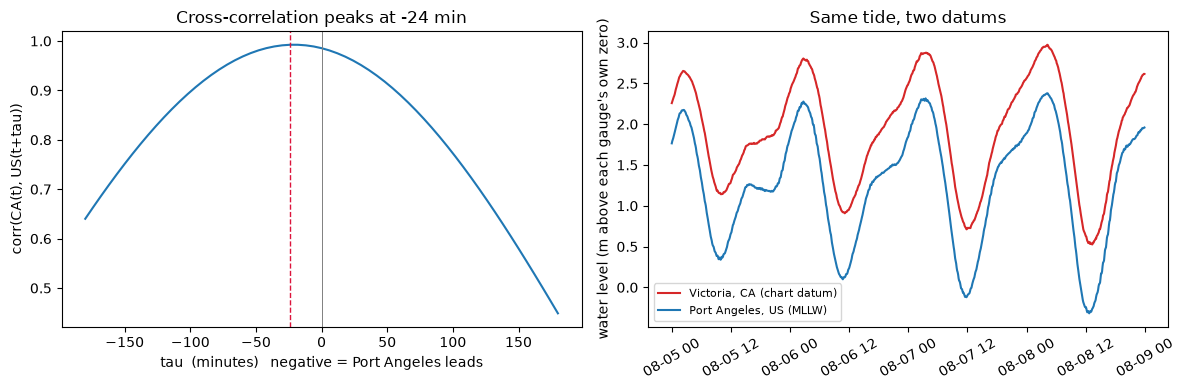

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(r_of_lag.index, r_of_lag.values, color="#1f77b4")
axes[0].axvline(peak, color="crimson", ls="--", lw=1)
axes[0].axvline(0, color="grey", lw=0.7)
axes[0].set_xlabel("tau  (minutes)   negative = Port Angeles leads")
axes[0].set_ylabel("corr(CA(t), US(t+tau))")
axes[0].set_title(f"Cross-correlation peaks at {peak:+d} min")

three_days = slice("2026-08-05", "2026-08-08")
axes[1].plot(paired.loc[three_days].index, paired.loc[three_days, "CA"],
             label="Victoria, CA (chart datum)", color="#d62728")
axes[1].plot(paired.loc[three_days].index, paired.loc[three_days, "US"],
             label="Port Angeles, US (MLLW)", color="#1f77b4")
axes[1].set_ylabel("water level (m above each gauge's own zero)")
axes[1].legend(fontsize=8)
axes[1].set_title("Same tide, two datums")
axes[1].tick_params(axis="x", rotation=30)
fig.tight_layout()
plt.show()

The peak is broad — r changes by 2 parts in 100,000 between -24 and -18 minutes — so "24
minutes" is not a precise number. And a single lag for the whole waveform is the wrong model
anyway, because a mixed tide is not one wave. Two independent checks.

### 10b. Check one: match the turning points directly

In [26]:
matched = []
for state in ("high", "low"):
    canadian, american = ca_turns[ca_turns.state == state], us_turns[us_turns.state == state]
    for stamp in canadian.index:
        nearest = int(np.argmin(np.abs(american.index - stamp)))
        gap = (american.index[nearest] - stamp).total_seconds() / 60
        if abs(gap) < 150:
            matched.append({"state": state, "us_leads_min": -gap})
matched = pd.DataFrame(matched)
print(f"matched turning points: {len(matched)}")
print(matched.groupby("state")["us_leads_min"]
      .agg(["count", "median", "mean", "std"]).round(1).to_string())
print(f"\noverall median: Port Angeles leads Victoria by "
      f"{matched.us_leads_min.median():.0f} min")

matched turning points: 38
       count  median  mean   std
state                           
high      18    -0.0   4.7  13.1
low       20    12.0  14.0  10.4

overall median: Port Angeles leads Victoria by 6 min


High waters arrive at essentially the same moment on both shores; **low waters arrive about
12 minutes earlier on the American side**. So there is no single lag — the wave is distorted,
and cross-correlation was averaging two different things.

### 10c. Check two: separate the tide into constituents

A least-squares harmonic fit to M2, S2, K1 and O1. Fourteen days separates K1 from O1 (13.66
days needed) but is marginally short for M2 from S2 (14.77 days needed), so I read S2 as
indicative only.

In [27]:
CONSTITUENTS = {"M2": 12.4206012, "S2": 12.0000000,
                "K1": 23.9344697, "O1": 25.8193417}


def harmonic_fit(series, constituents=CONSTITUENTS):
    """Least squares fit of y = a0 + sum_k A_k cos(w_k t - phi_k)."""
    hours = (series.index - series.index[0]).total_seconds().to_numpy() / 3600.0
    design = [np.ones_like(hours)]
    for period in constituents.values():
        w = 2 * np.pi / period
        design += [np.cos(w * hours), np.sin(w * hours)]
    matrix = np.column_stack(design)
    coef, *_ = np.linalg.lstsq(matrix, series.to_numpy(), rcond=None)
    fitted = {name: {"amplitude": float(np.hypot(coef[1 + 2 * i], coef[2 + 2 * i])),
                     "phase": float(np.arctan2(coef[2 + 2 * i], coef[1 + 2 * i]))}
              for i, name in enumerate(constituents)}
    return fitted, pd.Series(matrix @ coef, index=series.index)


fit_ca, curve_ca = harmonic_fit(paired.CA)
fit_us, curve_us = harmonic_fit(paired.US)

rows = []
for name, period in CONSTITUENTS.items():
    dphi = (fit_us[name]["phase"] - fit_ca[name]["phase"] + np.pi) % (2 * np.pi) - np.pi
    rows.append({"constituent": name, "period_h": period,
                 "amp_CA_m": fit_ca[name]["amplitude"],
                 "amp_US_m": fit_us[name]["amplitude"],
                 "amp_US/CA": fit_us[name]["amplitude"] / fit_ca[name]["amplitude"],
                 "US_leads_min": -dphi / (2 * np.pi) * period * 60})
print(pd.DataFrame(rows).round(3).to_string(index=False))
print()
print("variance explained:  CA %.4f   US %.4f" % (
    1 - (paired.CA - curve_ca).var() / paired.CA.var(),
    1 - (paired.US - curve_us).var() / paired.US.var()))
sanity = pd.Series({int(k * 6): curve_ca.corr(curve_us.shift(-int(k)))
                    for k in np.arange(-30, 31)})
print("sign check: the two FITTED curves cross-correlate to a peak at",
      int(sanity.idxmax()), "min, same as the data at", peak, "min")

constituent  period_h  amp_CA_m  amp_US_m  amp_US/CA  US_leads_min
         M2    12.421     0.423     0.570      1.350        16.730
         S2    12.000     0.117     0.167      1.424         9.956
         K1    23.934     0.731     0.760      1.040        29.287
         O1    25.819     0.482     0.504      1.046        26.975

variance explained:  CA 0.9788   US 0.9810
sign check: the two FITTED curves cross-correlate to a peak at -24 min, same as the data at -24 min


That resolves everything.

* This tide is **diurnally dominated**: K1 is 0.73 m at Victoria against M2's 0.42 m.
* The **semidiurnal** constituents are 35 to 42% larger at Port Angeles than at Victoria; the
  **diurnal** ones differ by 4 to 5%. Victoria sits where the semidiurnal tide is strongly
  attenuated on the way into the Strait of Georgia system, and this fit recovers that from two
  weeks of two countries' data.
* The **diurnal constituents lead by about 28 minutes; the semidiurnal ones by 10 to 17
  minutes**. Because K1 and O1 carry most of the energy, whole-signal cross-correlation lands
  near the diurnal lag — hence -24 minutes. Because high and low waters are set by the sum of
  the two, the turning-point lag came out somewhere in between and different for highs and
  lows.

97.9% and 98.1% of the variance in each record, from four constituents. Two national gauges,
independently sited, independently maintained, agreeing on the physics of one strait — with the
differences being real oceanography rather than a plumbing error. **That is the answer to
"do they agree?": they agree, and where they differ they differ for reasons I can name.**

## 11. The diurnal cycle across the strait

Air temperature is the other quantity all three platforms measure. The interesting question is
not the mean — it is the *shape of the day*, which says how maritime each site is.

`align()` hands back UTC. The diurnal cycle is a local-clock effect, so I convert back.

In [28]:
STATIONS = {"Race Rocks (CA, ECCC hourly)": "air_temperature@1016640",
            "Port Angeles (US, CO-OPS)": "air_temperature@noaa_nos_co_ops_9444090",
            "New Dungeness 46088 (US, mid-strait)": "air_temperature@gov-ndbc-46088"}
local_hour = hourly.index.tz_localize("UTC").tz_convert("America/Vancouver").hour
air = pd.DataFrame({label: hourly[column].to_numpy() for label, column in STATIONS.items()},
                   index=pd.Index(local_hour, name="local hour"))
diurnal = air.groupby(level=0).mean()

print(pd.DataFrame({"mean degC": air.mean().round(2),
                    "diurnal range degC": (diurnal.max() - diurnal.min()).round(2),
                    "warmest local hour": diurnal.idxmax(),
                    "coolest local hour": diurnal.idxmin()}).to_string())
print()
print("r between hourly anomalies from each site's own diurnal mean:")
anomaly = air - air.groupby(level=0).transform("mean")
print(anomaly.corr().round(3).to_string())

                                      mean degC  diurnal range degC  warmest local hour  coolest local hour
Race Rocks (CA, ECCC hourly)              13.74                3.88                  17                   7
Port Angeles (US, CO-OPS)                 14.22                3.37                  18                   5
New Dungeness 46088 (US, mid-strait)      12.86                2.20                  18                   5

r between hourly anomalies from each site's own diurnal mean:
                                      Race Rocks (CA, ECCC hourly)  Port Angeles (US, CO-OPS)  New Dungeness 46088 (US, mid-strait)
Race Rocks (CA, ECCC hourly)                                 1.000                      0.775                                 0.771
Port Angeles (US, CO-OPS)                                    0.775                      1.000                                 0.694
New Dungeness 46088 (US, mid-strait)                         0.771                      0.694                

Plotted, the three daily curves separate cleanly by how much water each site is surrounded by.

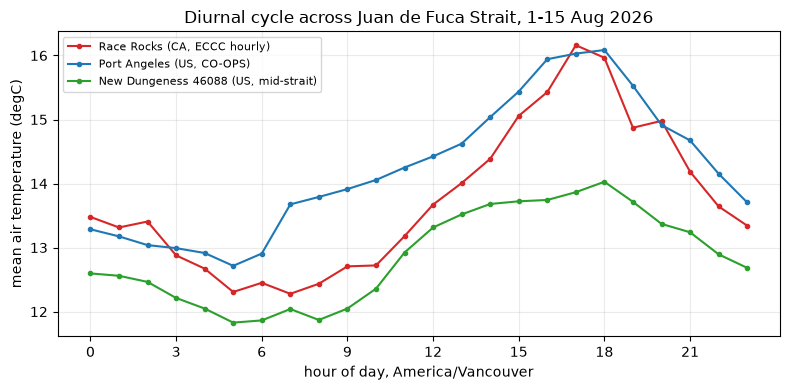

In [29]:
fig, ax = plt.subplots(figsize=(8, 4))
for label, colour in zip(STATIONS, ("#d62728", "#1f77b4", "#2ca02c")):
    ax.plot(diurnal.index, diurnal[label], marker="o", ms=3, label=label, color=colour)
ax.set_xlabel("hour of day, America/Vancouver")
ax.set_ylabel("mean air temperature (degC)")
ax.set_title("Diurnal cycle across Juan de Fuca Strait, 1-15 Aug 2026")
ax.set_xticks(range(0, 24, 3))
ax.grid(alpha=0.25)
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

The mid-channel buoy has the flattest day, 2.20 degC peak to trough — it is surrounded by
11.6 degC water and nothing else. Port Angeles, in a harbour with a mountain range behind it,
swings 3.37 degC and is the warmest site on average. Race Rocks, a bare rock a kilometre
offshore, swings **3.88 degC** — the largest of the three, which surprised me.

Both shore stations peak at 17:00-18:00 local; the buoy peaks at 18:00 and bottoms at 05:00.
The hour-to-hour anomalies correlate 0.69 to 0.78 across all three pairs, so they are living
in the same air mass; the differences are local, not synoptic.

That Race Rocks has a bigger diurnal range than a mainland harbour is worth a second look
rather than a conclusion — half a degree of diurnal range over a fortnight, at a
lighthouse whose sensor exposure I know nothing about. But it is the kind of question the cross-border frame is
for: without the American stations there is nothing to be surprised *against*.

## 12. Sea surface temperature three ways — and the hole in the Canadian record

Three US views of the water: a buoy thermistor at 1 m in mid-channel, a pier sensor at Port
Angeles, and NOAA CoastWatch's 5 km blended satellite analysis.

The gridded node cannot go through `align()` — it has latitude and longitude dimensions, so it
is not a time series, and `align()` says so and skips it. To use it I take the nearest pixel to
Race Rocks myself and put that back into the tree with `add_local()`, attributed to CoastWatch
rather than to me.

In [30]:
sst_grid = tree["/gridded/erddap/coastwatch/noaacwBLENDEDsstDNDaily"].dataset
pixel = sst_grid["analysed_sst"].sel(latitude=RACE_ROCKS.lat, longitude=RACE_ROCKS.lon,
                                     method="nearest")
print(f"nearest 5 km pixel: {float(pixel.latitude):.3f} N, {float(pixel.longitude):.3f} E"
      f"   units = {pixel.attrs['units']}")

extracted = pixel.to_series().rename("satellite_sst").to_frame().reset_index()
tree = omnisea.add_local(
    tree, extracted, name="CoastWatch blended SST at Race Rocks",
    lat=float(pixel.latitude), lon=float(pixel.longitude), station_id="CW-RACEROCKS",
    institution=sst_grid.attrs.get("institution"), license=sst_grid.attrs.get("license"),
    var_attrs={"satellite_sst": {"standard_name": "sea_surface_foundation_temperature",
                                 "units": "degree_C", "cell_methods": "time: mean",
                                 "long_name": "Nearest-pixel blended satellite SST"}})

daily = omnisea.align(tree, freq="1D")
SST = {"buoy 46088 (US, ~1 m)": "sea_surface_temperature",
       "Port Angeles pier (US)": "sea_water_temperature",
       "CoastWatch blended (US, 5 km)": "satellite_sst"}
sst = pd.DataFrame({label: daily[column] for label, column in SST.items()}).dropna(how="all")
print()
print(sst.round(2).to_string())
print()
print("means:", sst.mean().round(2).to_dict())
difference = sst.iloc[:, 2] - sst.iloc[:, 0]
print("satellite - buoy: mean %+.2f degC, sd %.2f, r %.3f" %
      (difference.mean(), difference.std(), sst.iloc[:, 2].corr(sst.iloc[:, 0])))
print("resampling rules:", {c: daily.attrs["omnisea_aggregation"][c] for c in SST.values()})

nearest 5 km pixel: 48.275 N, -123.525 E   units = degree_C


skipping node /gridded/erddap/coastwatch/noaacwBLENDEDsstDNDaily in align(): it is a 14x22x33 grid, not a time series — align() joins series onto one time axis and a grid has latitude, longitude besides time. Pick the cells you want first (ds.sel(latitude=..., longitude=..., method='nearest') or .isel()), then add_local() the result, which is what makes the cost of reading a grid explicit rather than accidental.



            buoy 46088 (US, ~1 m)  Port Angeles pier (US)  CoastWatch blended (US, 5 km)
time                                                                                    
2026-08-01                  11.23                   11.89                          10.66
2026-08-02                  11.23                   11.89                          10.62
2026-08-03                  11.15                   11.95                          11.05
2026-08-04                  11.23                   11.56                          11.34
2026-08-05                  11.32                   11.62                          11.79
2026-08-06                  11.81                   11.32                          11.79
2026-08-07                  12.11                   11.38                          11.74
2026-08-08                  12.23                   11.67                          11.76
2026-08-09                  12.04                   11.89                          11.62
2026-08-10          

And the same three SST series through the fortnight — the satellite tracking the warming trend
but not the day-to-day structure the in-situ sensors see.

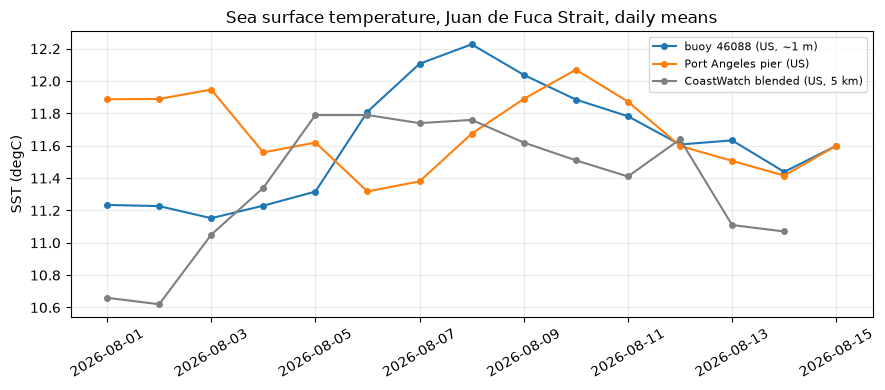

In [31]:
fig, ax = plt.subplots(figsize=(9, 4))
for label, colour in zip(SST, ("#1f77b4", "#ff7f0e", "#7f7f7f")):
    ax.plot(sst.index, sst[label], marker="o", ms=4, label=label, color=colour)
ax.set_ylabel("SST (degC)")
ax.set_title("Sea surface temperature, Juan de Fuca Strait, daily means")
ax.grid(alpha=0.25)
ax.legend(fontsize=8)
ax.tick_params(axis="x", rotation=30)
fig.tight_layout()
plt.show()

The two in-situ sensors agree to 0.06 degC in the mean, which for instruments roughly 30 km
apart in a well-mixed strait is about right. The satellite runs 0.26 degC cold against the buoy with a
scatter of 0.31 degC and correlates only r = 0.68 on daily values — a 5 km foundation-SST
analysis cannot resolve a strait 20 km wide with tidal mixing this vigorous, and it should not
be used as a substitute for the in-situ record here.

In [32]:
# is there really no Canadian in-water temperature in reach?
wide = omnisea.Site(48.298, -123.532, "Race Rocks", radius_km=120)
marine = omnisea.discover(sites=wide, time=WINDOW, providers="eccc_swob_marine")
print("ECCC marine buoys, searching out to 120 km:")
print(marine.frame.nsmallest(3, "distance_km")[
    ["station_id", "name", "distance_km"]].to_string(index=False))

meds = omnisea.discover(sites=RACE_ROCKS, time=WINDOW, providers="erddap_tabledap",
                        erddap_server="cioos_pacific", erddap_datasets=["DFO_MEDS_BUOYS"])
print("\nCIOOS Pacific DFO_MEDS_BUOYS (ECCC buoy archive), declared extent:")
print(meds.frame[["station_id", "first", "last", "n_rows_est"]].to_string(index=False))

ECCC marine buoys, searching out to 120 km:
station_id                    name  distance_km
   9102000 Southern Georgia Strait    81.185175
   9102001 Entrance to English Bay   112.339137
   9100552            HALIBUT BANK   116.738766

CIOOS Pacific DFO_MEDS_BUOYS (ECCC buoy archive), declared extent:
    station_id first last  n_rows_est
DFO_MEDS_BUOYS  None None        2016


**And every one of those three series is American.** There is no Canadian in-water temperature
in this notebook, and not for want of asking:

* `eccc_swob_marine` has no buoy within 60 km — the nearest is 81 km away in Georgia Strait.
* CIOOS Pacific's `DFO_MEDS_BUOYS` aggregate stops at 2025-03-18.
* Ocean Networks Canada runs a cabled instrument platform *at Race Rocks*, which would close
  the gap exactly — and it is the one source in omnisea that needs a credential, so without an
  `ONC_TOKEN` it is simply absent.

That asymmetry is worth stating plainly in any synthesis built this way. The Canadian side of
this strait contributes sea level and weather to my frame; the water temperature is entirely
American.

## 13. Attribution — the part that decides whether this is publishable

Five institutions, two countries, two licensing regimes. A methods section has to name all of
them correctly.

In [33]:
print(omnisea.provenance(tree)[
    ["source", "institution", "n_stations", "n_values"]].to_string(index=False))
print()
for _, row in omnisea.provenance(tree, by="provider")[
        ["provider", "institution", "license", "terms"]].iterrows():
    print(f"{row.provider:<8s} {row.institution[:56]}")
    print(f"         licence: {str(row.license)[:96]}")
    print(f"         terms  : {row.terms}")

            source                                                              institution  n_stations  n_values
         dfo_tides              Fisheries and Oceans Canada / Canadian Hydrographic Service           1      6763
      eccc_climate Environment and Climate Change Canada / Meteorological Service of Canada           1       337
eccc_climate_daily Environment and Climate Change Canada / Meteorological Service of Canada           1        15
         eccc_swob Environment and Climate Change Canada / Meteorological Service of Canada           1     19672
    erddap_griddap                                                   NOAA NESDIS CoastWatch           0        14
   erddap_tabledap NOAA Center for Operational Oceanographic Products and Services (CO-OPS)           1      3361
   erddap_tabledap                                    NOAA National Data Buoy Center (NDBC)           1      2043
             local                                                   NOAA NESDIS CoastWa

The Canadian side is exactly right: both DFO and ECCC come out under the Open Government
Licence - Canada, each with the correct terms URL for that department. If I paste those two
lines into a paper they are correct.

The American side is not. All four NOAA rows carry the same terms URL,
`https://coastwatch.pfeg.noaa.gov/erddap/information.html` — which is the *ERDDAP software*
information page at NOAA's Pacific Fisheries Environmental Lab. It is not NDBC's terms, not
CO-OPS's terms, and not GHRSST's, and the CoastWatch row is especially wrong: its licence text
correctly says "GHRSST protocol describes data use as free and open" and then points at a page
about ERDDAP. The licences themselves are read from each dataset and are right; only the terms
link is a provider-level default that should not have survived onto a per-dataset row.

Also note `provider` reads `erddap` for all four. ERDDAP is a piece of software, not an
organization; the institution column has the real answer, but a naive `groupby("provider")`
would credit four NOAA line offices to a web server.

In [34]:
print(omnisea.citation(tree))

Data were retrieved with omnisea 0.1.0 on 2026-08-27T21:57:05+00:00 from 7 source(s) across 5 station(s), covering 2026-08-01 to 2026-08-15.

  Fisheries and Oceans Canada / Canadian Hydrographic Service — dfo_tides (1 station(s), 2026-08-01 to 2026-08-15): Victoria Harbour (07120). Licence: Fisheries and Oceans Canada — Open Government Licence – Canada. Terms: https://open.canada.ca/en/open-government-licence-canada
  Environment and Climate Change Canada / Meteorological Service of Canada — eccc_climate (1 station(s), 2026-08-01 to 2026-08-15): RACE ROCKS (1016640). Licence: Environment and Climate Change Canada — Open Government Licence – Canada. Terms: https://eccc-msc.github.io/open-data/licence/readme_en/
  Environment and Climate Change Canada / Meteorological Service of Canada — eccc_climate_daily (1 station(s), 2026-08-01 to 2026-08-15): RACE ROCKS (1016640). Licence: Environment and Climate Change Canada — Open Government Licence – Canada. Terms: https://eccc-msc.github.io/op

Seven sources, five stations, both countries, every licence named. That block is close to
paste-ready and it is the single best thing in the library — I did not have to remember which
of these agencies wants what.

Two blemishes on it. The CoastWatch griddap line reads `(0 station(s), ...): nan` — a literal
`nan` where a station name would go, because a grid has no station, and a count of zero
immediately before a name is listed. It is the one line in an otherwise publication-ready
block that I would have to hand-edit. And the two NOAA in-situ entries each inline the full
120-word IOOS disclaimer, which makes the block four times longer than it needs to be.

## 14. Save it

netCDF groups, losslessly, including the gridded node and my extracted pixel.

In [35]:
import xarray as xr

omnisea.to_netcdf(tree, "juan_de_fuca.nc")
reopened = xr.open_datatree("juan_de_fuca.nc")
groups = [n.path for n in reopened.subtree if n.dataset.data_vars]
print(f"wrote juan_de_fuca.nc - {len(groups)} groups round-tripped\n")
print("\n".join(groups))
print()
print("query recorded on the root:",
      {k: v for k, v in reopened.attrs.items() if k.startswith("query_")})

wrote juan_de_fuca.nc - 9 groups round-tripped

/in_situ/tides/07120
/in_situ/weather/1016640
/in_situ/weather_daily/1016640
/in_situ/weather_realtime/1016640
/in_situ/local/CW-RACEROCKS
/predictions/tides_hilo/07120
/in_situ/erddap/ioos_sensors/noaa_nos_co_ops_9444090
/in_situ/erddap/ioos_sensors/gov-ndbc-46088
/gridded/erddap/coastwatch/noaacwBLENDEDsstDNDaily

query recorded on the root: {'query_start': '2026-08-01T00:00:00+00:00', 'query_end': '2026-08-15T00:00:00+00:00', 'query_bbox': array([-124.34310412,   47.75840778, -122.72089588,   48.83759222]), 'query_site_names': '["Race Rocks"]', 'query_site_lats': '[48.298]', 'query_site_lons': '[-123.532]', 'query_site_radius_km': '[60]', 'query_providers': 'dfo_tides, eccc_climate, eccc_climate_daily, eccc_swob, erddap_tabledap'}


## 15. What I would tell a colleague

**Can I assemble a cross-border picture of one strait from a single query?** Nearly. One
`discover()` call reached 62 Canadian stations from four DFO and ECCC collections and 35
American ones through the IOOS ERDDAP, and one `fetch()` pulled five institutions into one
tree with everything's provenance attached. The only thing that needed a second call was the
satellite grid, because a list of dataset ids cannot span two ERDDAP servers. Compared with
writing four API clients, this is not close.

**Do the two countries' data agree?** Yes, and the disagreements are physical.

* Sea level correlates at **r = 0.985** between Victoria and Port Angeles over 3361 paired
  6-minute samples, with no cross-calibration.
* A four-constituent harmonic fit explains **98%** of each record and shows the semidiurnal
  tide 35-42% larger at Port Angeles while the diurnal tide differs by 4-5% — real strait
  physics, recovered from two national datasets that have never been compared to each other.
* Barometers 20-26 km apart across the boundary agree at r = 0.991-0.996.
* In-situ SST at the buoy and the pier agree to **0.06 degC** in the mean; the 5 km satellite
  analysis runs 0.26 degC cold and correlates at only r = 0.68 daily.

**What would have gone wrong if I had trusted the frame.** Three things, and all three are
invisible in the numbers:

1. `to_cf_units=True` converts the Canadian columns and not the American ones. It would have
   put kelvin next to degrees Celsius in one frame.
2. The American water level is named `sea_surface_height_above_sea_level` but is on **MLLW**;
   the upstream `vertical_datum` attribute did not survive into the tree. The 0.64 m offset
   against the Canadian gauge has no explanation anywhere in the object.
3. `drop_correlated()` deleted both American sea-level columns, and both mean-sea-level
   pressure columns (one Canadian, one American), as redundant with columns in different
   units and on a different datum. The audit trail records only `r` and `n`.

**What I would do differently next time.** Fetch with the default units. Read `source_field` on
every ERDDAP variable before believing its name. Pin the columns whose datum I have checked
with `drop_correlated(keep=...)`. And check `omnisea_units` and `omnisea_aggregation` before
plotting anything — both of them are there, and both of them told me something I would
otherwise have got wrong.